In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("Alle Pakete geladen ✓")

Alle Pakete geladen ✓


In [2]:
np.random.seed(42)
n = 1000

druck = np.random.normal(150, 20, n)
temperatur = np.random.normal(75, 10, n)
durchfluss = np.random.normal(50, 8, n)
vibration = np.random.normal(0.5, 0.1, n)
betriebsstunden = np.random.uniform(0, 10000, n)

# Ausfallwahrscheinlichkeit — steigt mit Temperatur, Vibration und Betriebsstunden
ausfall = (
    0.3 * (temperatur / 100) +
    0.4 * (vibration / 1.0) +
    0.2 * (betriebsstunden / 10000) +
    0.1 * (druck / 200) +
    np.random.normal(0, 0.05, n)
).clip(0, 1)

df = pd.DataFrame({
    'Druck': druck,
    'Temperatur': temperatur,
    'Durchfluss': durchfluss,
    'Vibration': vibration,
    'Betriebsstunden': betriebsstunden,
    'Ausfall': ausfall
})

print(df.shape)
print(df.head())

(1000, 6)
        Druck  Temperatur  Durchfluss  Vibration  Betriebsstunden   Ausfall
0  159.934283   88.993554   44.598574   0.309219      4850.179875  0.560133
1  147.234714   84.246337   48.843851   0.413961       854.030302  0.445821
2  162.953771   75.596304   43.660641   0.458639      9724.613900  0.710523
3  180.460597   68.530632   47.536308   0.688769      5180.104314  0.577463
4  145.316933   81.982233   34.851083   0.555655      6141.862443  0.561187


In [3]:
# Features und Ziel trennen
X = df.drop('Ausfall', axis=1)
y = df['Ausfall']

# Train/Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost trainieren
model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model.fit(X_train, y_train)

# Vorhersagen + Ergebnisse
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.0581
R²:   0.5874


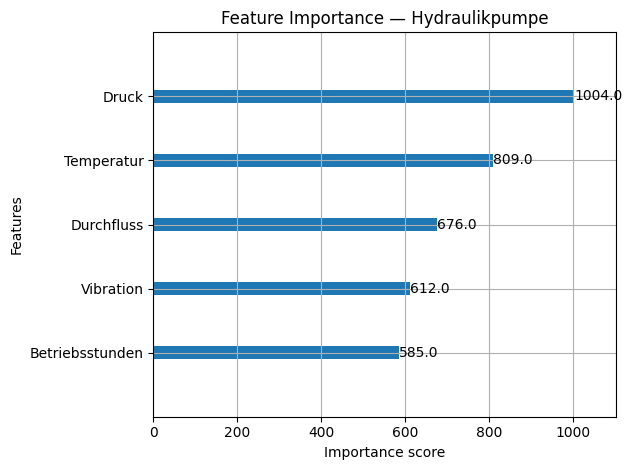

In [4]:
xgb.plot_importance(model)
plt.title("Feature Importance — Hydraulikpumpe")
plt.tight_layout()
plt.show()

In [5]:
import joblib
joblib.dump(model, 'model_v1.pkl')
print("Modell gespeichert ✓")

Modell gespeichert ✓


In [6]:
# Eine konkrete Maschine
maschine = pd.DataFrame({
    'Druck': [162],
    'Temperatur': [88],
    'Durchfluss': [50],
    'Vibration': [0.71],
    'Betriebsstunden': [8500]
})

vorhersage = model.predict(maschine)
print(f"Ausfallwahrscheinlichkeit: {vorhersage[0]:.1%}")

Ausfallwahrscheinlichkeit: 84.2%


In [7]:
gesunde_maschine = pd.DataFrame({
    'Druck': [148],
    'Temperatur': [65],
    'Durchfluss': [52],
    'Vibration': [0.45],
    'Betriebsstunden': [1200]
})

vorhersage2 = model.predict(gesunde_maschine)
print(f"Ausfallwahrscheinlichkeit: {vorhersage2[0]:.1%}")

Ausfallwahrscheinlichkeit: 45.2%


In [8]:
model_es = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50
)

model_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_es = model_es.predict(X_test)
rmse_es = mean_squared_error(y_test, y_pred_es) ** 0.5
print(f"RMSE vorher: 0.0581")
print(f"RMSE jetzt:  {rmse_es:.4f}")

RMSE vorher: 0.0581
RMSE jetzt:  0.0531


In [9]:
joblib.dump(model_es, 'model_v2.pkl')
print("Verbessertes Modell gespeichert ✓")

Verbessertes Modell gespeichert ✓


In [10]:
# Dieselbe kranke Maschine wie vorher
maschine = pd.DataFrame({
    'Druck': [162],
    'Temperatur': [88],
    'Durchfluss': [50],
    'Vibration': [0.71],
    'Betriebsstunden': [8500]
})

v1 = model.predict(maschine)[0]
v2 = model_es.predict(maschine)[0]

print(f"Modell v1 (ohne Early Stopping): {v1:.1%}")
print(f"Modell v2 (mit Early Stopping):  {v2:.1%}")

Modell v1 (ohne Early Stopping): 84.2%
Modell v2 (mit Early Stopping):  81.1%


In [11]:
# R² für beide Modelle vergleichen
r2_v1 = r2_score(y_test, model.predict(X_test))
r2_v2 = r2_score(y_test, model_es.predict(X_test))

print(f"Modell v1 — RMSE: 0.0581 | R²: {r2_v1:.4f}")
print(f"Modell v2 — RMSE: 0.0531 | R²: {r2_v2:.4f}")
print(f"\nVerbesserung RMSE: {((0.0581 - 0.0531) / 0.0581 * 100):.1f}%")

Modell v1 — RMSE: 0.0581 | R²: 0.5874
Modell v2 — RMSE: 0.0531 | R²: 0.6554

Verbesserung RMSE: 8.6%
